In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
df.shape

(768, 9)

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

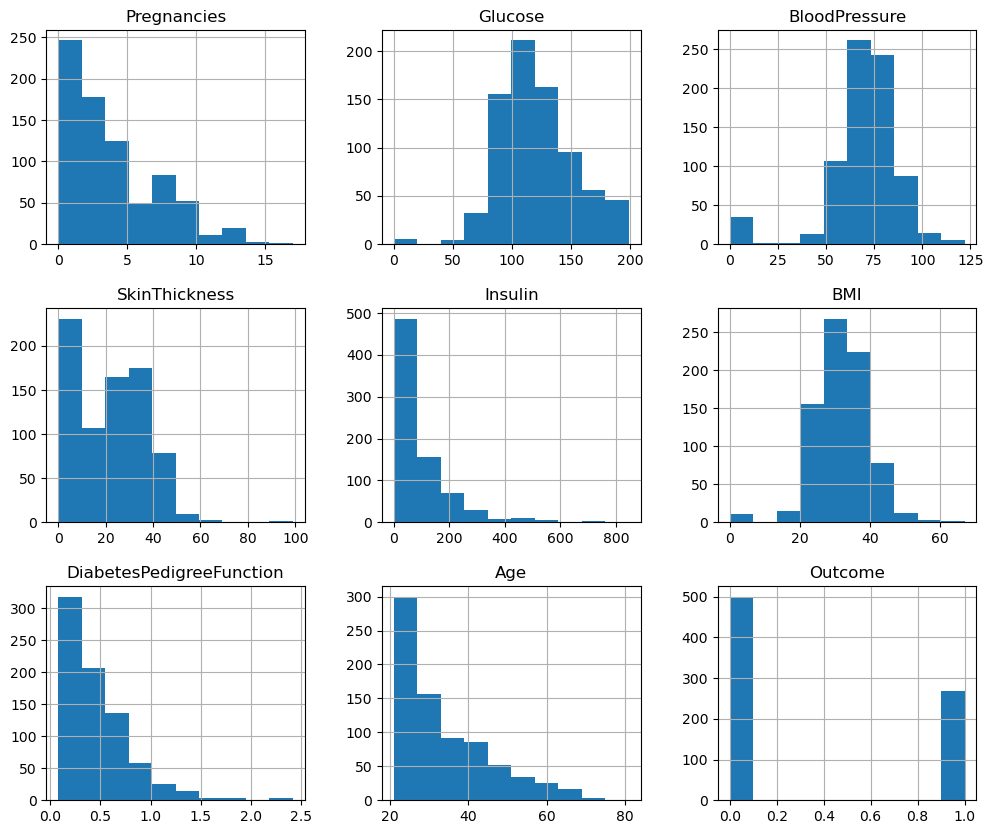

In [10]:
df.hist(figsize=(12, 10))
plt.show()

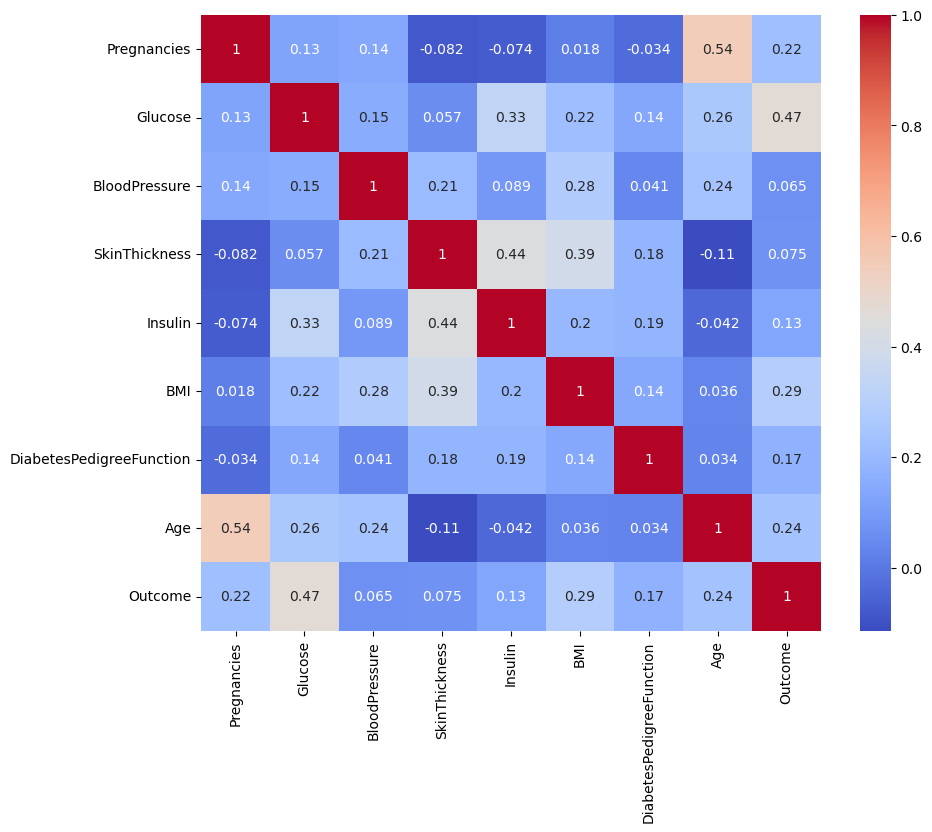

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot= True, cmap= 'coolwarm')
plt.show()

In [13]:
x= df.drop("Outcome", axis=1)
y= df["Outcome"]

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size= 0.2,
    random_state= 42
)

In [15]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [16]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [17]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred= model.predict(x_test)

In [19]:
comparision= pd.DataFrame({
    "Actual":y_test,
    "Predict":y_pred
})
comparision.head()

,Actual,Predict
668,0,0
324,0,0
624,0,0
690,0,0
473,0,0


In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7532467532467533

In [23]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print(cm)

[[79 20]
 [18 37]]


In [26]:
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.6491228070175439

In [27]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.6727272727272727

In [28]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.6607142857142857

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



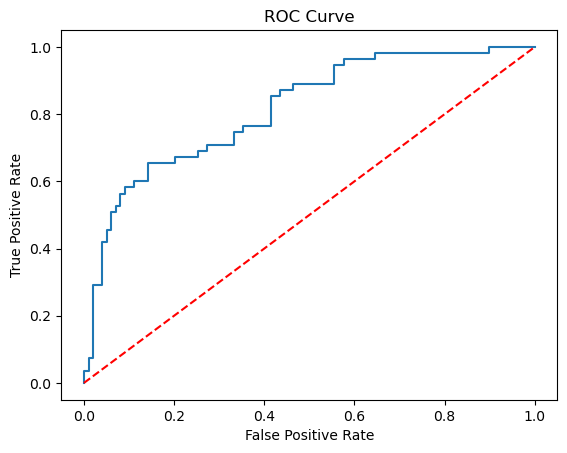

In [35]:
from sklearn.metrics import roc_curve
y_prob= model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds= roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [36]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

0.8146923783287419

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5)

In [38]:
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred_knn= knn.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_knn)

0.6948051948051948

In [41]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred_knn)
print(cm)

[[79 20]
 [27 28]]


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



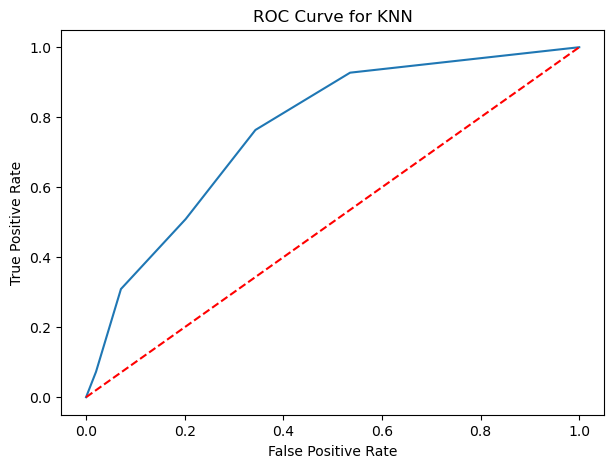

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_knn= knn.predict_proba(x_test)[:,1]
fpr, tpr, thresholds= roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for KNN")
plt.show()

In [44]:
roc_auc_score(y_test, y_prob_knn)

0.7640955004591368

In [45]:
accuracy= []
for k in range(1, 21):
    knn= KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    pred= knn.predict(x_test)
    accuracy.append(accuracy_score(y_test, pred))

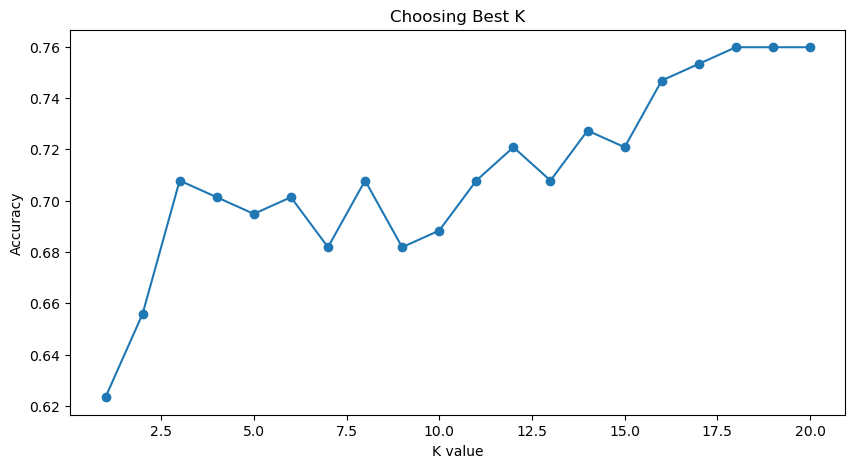

In [48]:
plt.figure(figsize=(10,5))
plt.plot(range(1,21), accuracy, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Choosing Best K")
plt.show()